### Comparaison des différents modèles scikit-learn vs pyspark

In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# importation des données
with open("../data/model_metrics_sklearn_comparaison.json", "r") as f:
    sklearn_results_comparaison = json.load(f)

with open("../data/model_results_pyspark_comparaison.json", "r") as f:
    spark_results_comparaison = json.load(f)
    
with open("../data/model_metrics_sklearn_best_model_.json", "r") as f:
    sklearn_results_best_model = json.load(f)

with open("../data/model_results_pyspark_best_model.json", "r") as f:
    spark_results_best_model = json.load(f)

### Comparaison des scores d’accuracy, de précision, de rappel et de F1 pour les trois modèles testés avec scikit-learn : Logistic Regression, Random Forest et Gradient Boosting.

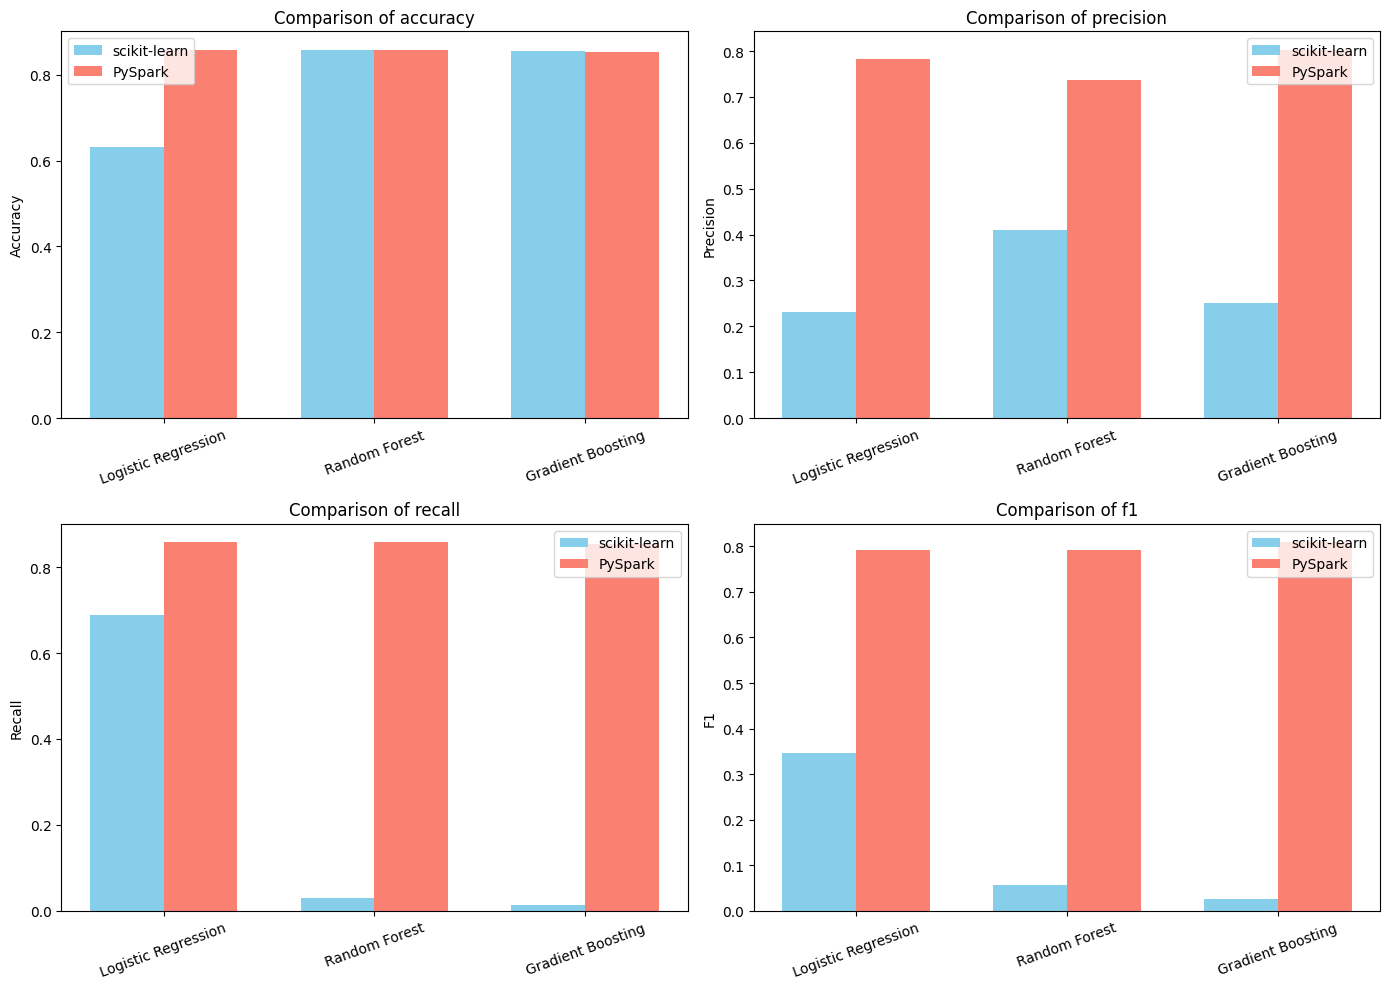

In [6]:
metrics = ["accuracy", "precision", "recall", "f1"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sklearn_vals = [v[metric] for v in sklearn_results_comparaison.values()]
    spark_vals = [v[metric] for v in spark_results_comparaison.values()]
    labels = list(sklearn_results_comparaison.keys())

    x = np.arange(len(labels))
    width = 0.35

    axes[i].bar(x - width/2, sklearn_vals, width, label="scikit-learn", color='skyblue')
    axes[i].bar(x + width/2, spark_vals, width, label="PySpark", color='salmon')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(labels, rotation=20)
    axes[i].set_ylabel(metric.capitalize())
    axes[i].set_title(f"Comparison of {metric}")
    axes[i].legend()

plt.tight_layout()

### Comparaison du meilleur modèle scikit-learn vs pyspark

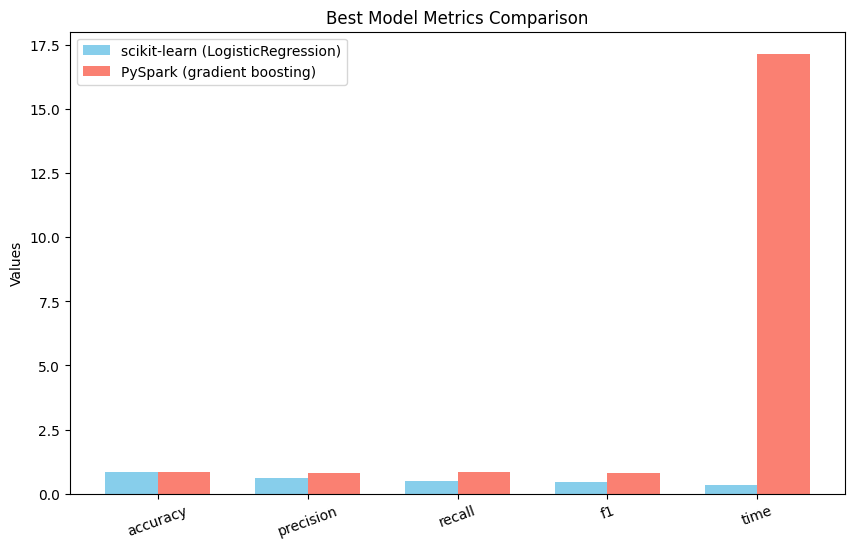

In [7]:
best_sklearn_name = list(sklearn_results_best_model.keys())[0]
best_spark_name = list(spark_results_best_model.keys())[0]

best_sklearn_vals = list(sklearn_results_best_model[best_sklearn_name].values())
best_spark_vals = list(spark_results_best_model[best_spark_name].values())
best_metrics_labels = list(sklearn_results_best_model[best_sklearn_name].keys())

x = np.arange(len(best_metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width/2, best_sklearn_vals, width, label=f"scikit-learn ({best_sklearn_name})", color='skyblue')
ax.bar(x + width/2, best_spark_vals, width, label=f"PySpark ({best_spark_name})", color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(best_metrics_labels, rotation=20)
ax.set_ylabel("Values")
ax.set_title("Best Model Metrics Comparison")
ax.legend()
plt.show()

### Comparaison du temps d'execution scikit-learn vs pyspark

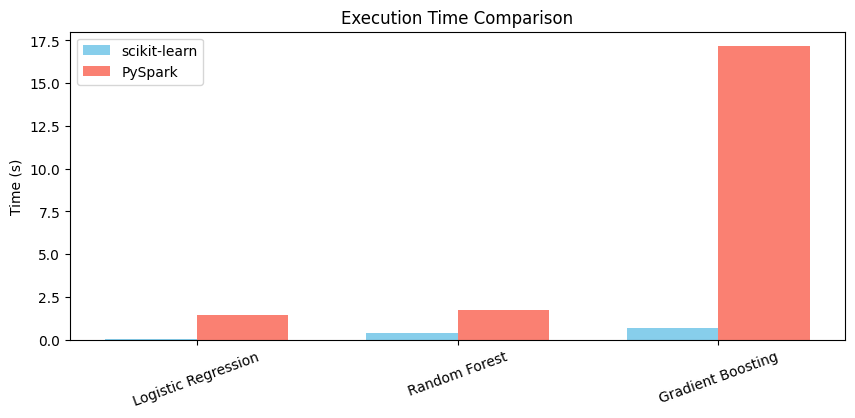

In [8]:
time_sklearn = [v["time"] for v in sklearn_results_comparaison.values()]
time_spark = [v["time"] for v in spark_results_comparaison.values()]

fig, ax = plt.subplots(figsize=(10,4))
x = np.arange(len(labels))
ax.bar(x - width/2, time_sklearn, width, label="scikit-learn", color='skyblue')
ax.bar(x + width/2, time_spark, width, label="PySpark", color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20)
ax.set_ylabel("Time (s)")
ax.set_title("Execution Time Comparison")
ax.legend()
plt.show()